In [54]:
"""
=============================================================================
CAUSAL INFERENCE WITH INVERSE PROBABILITY WEIGHTING (IPW)
=============================================================================

PROBLEM STATEMENT:
-----
You are a Data Scientist at a large e-commerce platform. The Growth team
ran a targeted email campaign offering a 10% discount coupon to "high-value"
users - users who had made at least 2 purchases in the last 90 days.

Because the treatment (receiving the coupon) was NOT randomly assigned -
it was deliberately sent to high-value users - a naive comparison of
"coupon receivers vs non-receivers" will be BIASED. High-value users would
likely have spent more anyway.

Your job: Use Inverse Probability Weighting (IPW) to estimate the TRUE
causal effect of the coupon on spending in the next 30 days.

You have two datasets:
  - Dataset A: The coupon DID have a real causal effect on spending
  - Dataset B: The coupon had NO real causal effect on spending

By the end, you should recover the true treatment effect (or lack of it)
after properly adjusting for confounding.

KEY CONCEPTS COVERED:
  1. Confounding and selection bias
  2. Propensity score estimation
  3. IPW (Horvitz-Thompson estimator)
  4. Stabilized weights
  5. Weight trimming and overlap diagnostics
  6. Positivity assumption checks
  7. Covariate balance (Standardized Mean Differences)
  8. ATE estimation and confidence intervals via bootstrap
  9. Sensitivity to model misspecification

=============================================================================
"""

'\n=============================================================================\nCAUSAL INFERENCE WITH INVERSE PROBABILITY WEIGHTING (IPW)\n=============================================================================\n\nPROBLEM STATEMENT:\n-----\nYou are a Data Scientist at a large e-commerce platform. The Growth team\nran a targeted email campaign offering a 10% discount coupon to "high-value"\nusers - users who had made at least 2 purchases in the last 90 days.\n\nBecause the treatment (receiving the coupon) was NOT randomly assigned -\nit was deliberately sent to high-value users - a naive comparison of\n"coupon receivers vs non-receivers" will be BIASED. High-value users would\nlikely have spent more anyway.\n\nYour job: Use Inverse Probability Weighting (IPW) to estimate the TRUE\ncausal effect of the coupon on spending in the next 30 days.\n\nYou have two datasets:\n  - Dataset A: The coupon DID have a real causal effect on spending\n  - Dataset B: The coupon had NO real causal

In [ ]:
# Propensity Score Matching (PSM) finds, for each treated user, 
# the one (or few) control users with the most similar propensity score, and pairs them. 
# Everyone else gets dropped. You end up with a matched sample of equal size treated and control, 
# and then you just compute the mean difference in outcomes on that matched sample.
# IPW keeps everyone. Instead of dropping anyone, it reweights all users so that the weighted distribution of covariates
# is the same in treated and control. No one is discarded.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [3]:
# =============================================================================
# SECTION 1: DATA GENERATION
# =============================================================================

In [4]:
def generate_dataset(n=5000, true_ate=15.0, seed=42):
    """
    Generates a simulated observational dataset of users for the coupon campaign.

    What this function does:
    - Creates 'n' users with realistic background features (confounders)
    - Assigns treatment (coupon) non-randomly - users with better profiles
      are MORE likely to receive the coupon (this mimics real targeting logic)
    - Generates the outcome (spending) that is influenced by both the
      confounders AND (optionally) the treatment
    - The 'true_ate' parameter is the TRUE causal effect we want to recover.
      If true_ate=0, there is no real effect.

    Parameters:
        n         : number of users to simulate
        true_ate  : the real causal lift from the coupon on spending (in dollars)
        seed      : random seed for reproducibility

    Returns:
        A pandas DataFrame with one row per user.
    """
    rng = np.random.default_rng(seed)

    # - Confounders (variables that affect BOTH treatment AND outcome) -
    # These are the variables that create selection bias if ignored.

    # Number of purchases in the last 90 days (main targeting variable)
    past_purchases = rng.negative_binomial(n=3, p=0.4, size=n)
    past_purchases = np.clip(past_purchases, 0, 20)

    # Average order value in USD
    avg_order_value = rng.gamma(shape=3, scale=20, size=n) + 20

    # Account age in months
    account_age = rng.gamma(shape=2, scale=18, size=n) + 1

    # Whether the user is a mobile-only user (tends to spend less)
    is_mobile = rng.binomial(1, 0.45, size=n)

    # User's historical engagement score (0 to 1)
    engagement_score = rng.beta(a=2, b=3, size=n)

    # - Propensity Score (probability of receiving coupon) -
    # This is the TRUE propensity score used to generate data.
    # The coupon is more likely to go to users with more past purchases,
    # higher order values, and higher engagement. This is the CONFOUNDING.
    log_odds = (
        -1.5
        + 0.25 * past_purchases
        + 0.015 * avg_order_value
        + 0.01 * account_age
        - 0.4 * is_mobile
        + 1.2 * engagement_score
    )
    true_propensity = 1 / (1 + np.exp(-log_odds))

    # Assign treatment based on true propensity (this is the non-random part)
    treatment = rng.binomial(1, true_propensity, size=n)

    # - Outcome: Spending in the next 30 days -
    # Spending is driven by confounders + random noise + treatment effect.
    # Notice: confounders independently push spending UP for treated users -
    # that's exactly what creates bias in a naive comparison.
    baseline_spending = (
        5
        + 2.5 * past_purchases
        + 0.3 * avg_order_value
        + 0.05 * account_age
        - 8 * is_mobile
        + 15 * engagement_score
        + rng.normal(0, 10, size=n)
    )

    # The TRUE causal effect: only exists if true_ate != 0
    spending = baseline_spending + true_ate * treatment
    spending = np.clip(spending, 0, None)  # spending can't be negative

    df = pd.DataFrame({
        "past_purchases": past_purchases,
        "avg_order_value": avg_order_value,
        "account_age": account_age,
        "is_mobile": is_mobile,
        "engagement_score": engagement_score,
        "true_propensity": true_propensity,
        "treatment": treatment,
        "spending": spending,
    })

    return df


In [5]:
# Generate the two datasets
df_effect = generate_dataset(n=5000, true_ate=15.0, seed=42)
df_no_effect = generate_dataset(n=5000, true_ate=0.0, seed=42)

In [6]:
df_effect.head()

,past_purchases,avg_order_value,account_age,is_mobile,engagement_score,true_propensity,treatment,spending
0,6,63.756287,38.329209,1,0.560839,0.833778,1,60.546951
1,4,42.876142,48.572233,0,0.331419,0.736250,1,48.060648
2,9,64.122401,33.031498,0,0.357590,0.922102,1,59.483530
3,6,93.068290,25.036738,1,0.156218,0.807501,0,31.798224
4,4,64.163034,15.984154,1,0.092943,0.582688,0,29.680864


In [7]:
df_no_effect.head()

,past_purchases,avg_order_value,account_age,is_mobile,engagement_score,true_propensity,treatment,spending
0,6,63.756287,38.329209,1,0.560839,0.833778,1,45.546951
1,4,42.876142,48.572233,0,0.331419,0.736250,1,33.060648
2,9,64.122401,33.031498,0,0.357590,0.922102,1,44.483530
3,6,93.068290,25.036738,1,0.156218,0.807501,0,31.798224
4,4,64.163034,15.984154,1,0.092943,0.582688,0,29.680864


In [8]:
print("=" * 60)
print("DATASET A (True ATE = $15.00): Coupon has a REAL effect")
print("=" * 60)
print(df_effect.describe().round(2))

print("\n" + "=" * 60)
print("DATASET B (True ATE = $0.00): Coupon has NO effect")
print("=" * 60)
print(df_no_effect.describe().round(2))

DATASET A (True ATE = $15.00): Coupon has a REAL effect
       past_purchases  avg_order_value  account_age  is_mobile  \
count         5000.00          5000.00      5000.00    5000.00   
mean             4.51            79.86        36.64       0.45   
std              3.39            34.69        24.80       0.50   
min              0.00            21.60         1.31       0.00   
25%              2.00            54.43        18.26       0.00   
50%              4.00            73.47        30.83       0.00   
75%              6.00            98.47        48.96       1.00   
max             20.00           325.61       192.28       1.00   

       engagement_score  true_propensity  treatment  spending  
count           5000.00          5000.00    5000.00   5000.00  
mean               0.40             0.77       0.77     55.98  
std                0.20             0.15       0.42     20.01  
min                0.01             0.25       0.00      0.00  
25%                0.24      

In [9]:
# Both datasets look similar on the surface. The difference is only
# in how the outcome 'spending' was constructed. This is the whole challenge
# of causal inference - you can't just look at the data and tell the difference.

In [10]:
# =============================================================================
# SECTION 2: NAIVE COMPARISON (THE WRONG WAY)
# =============================================================================

def naive_ate(df):
    """
    Computes the naive (biased) Average Treatment Effect by simply subtracting
    the mean spending of the control group from the mean spending of the
    treated group.

    What this function does:
    - Takes the raw average for treated users
    - Takes the raw average for control users
    - Returns the difference

    This is WRONG in observational data because treated and control users
    are fundamentally different people (higher-value users got the coupon).
    The difference in outcomes is NOT just from the coupon.

    Returns:
        (ate_estimate, treated_mean, control_mean)
    """
    treated_mean = df[df.treatment == 1]["spending"].mean()
    control_mean = df[df.treatment == 0]["spending"].mean()
    return treated_mean - control_mean, treated_mean, control_mean

In [11]:
naive_a, t_a, c_a = naive_ate(df_effect)
naive_b, t_b, c_b = naive_ate(df_no_effect)

In [12]:
print("\n" + "=" * 60)
print("NAIVE (BIASED) ESTIMATES")
print("=" * 60)
print(f"Dataset A (True ATE=$15): Naive estimate = ${naive_a:.2f}")
print(f"  Treated mean: ${t_a:.2f} | Control mean: ${c_a:.2f}")
print(f"\nDataset B (True ATE=$0):  Naive estimate = ${naive_b:.2f}")
print(f"  Treated mean: ${t_b:.2f} | Control mean: ${c_b:.2f}")


NAIVE (BIASED) ESTIMATES
Dataset A (True ATE=$15): Naive estimate = $25.50
  Treated mean: $61.77 | Control mean: $36.27

Dataset B (True ATE=$0):  Naive estimate = $10.50
  Treated mean: $46.77 | Control mean: $36.27


In [13]:
# You will see both naive estimates are far too HIGH.
# Even in Dataset B where there is ZERO real effect, the naive estimate
# shows a large positive number. That's pure confounding bias - higher-value
# users were both more likely to get the coupon AND more likely to spend more.

In [14]:
# =============================================================================
# SECTION 3: PROPENSITY SCORE ESTIMATION
# =============================================================================

In [15]:
COVARIATES = ["past_purchases", "avg_order_value", "account_age",
              "is_mobile", "engagement_score"]

In [16]:
def estimate_propensity(df, covariates):
    """
    Estimates the propensity score: the probability that each user received
    the coupon (treatment=1), given their observed background features.

    What this function does:
    - Takes the observed user features (covariates) as inputs
    - Fits a logistic regression to predict P(treatment=1 | covariates)
    - Returns the estimated probability for each user

    This is the core of IPW. We are asking:
    "Given everything I know about this user, how likely were they to get
    the coupon?"

    WATCH OUT FOR:
    - Propensity scores very close to 0 or 1 (extreme weights, see Section 4)
    - Omitting important confounders (the model must include all variables
      that affect BOTH treatment and outcome)
    - Model misspecification (logistic regression assumes linearity on the
      log-odds scale; consider adding interactions or using a tree-based model)

    Parameters:
        df         : the dataset
        covariates : list of column names to use as features

    Returns:
        Array of estimated propensity scores (one per user)
    """
    X = df[covariates].values
    y = df["treatment"].values

    # Standardize features - important for logistic regression convergence
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LogisticRegression(max_iter=1000, C=1.0)
    model.fit(X_scaled, y)

    propensity_scores = model.predict_proba(X_scaled)[:, 1]
    return propensity_scores

In [17]:
df_effect["ps"] = estimate_propensity(df_effect, COVARIATES)
df_no_effect["ps"] = estimate_propensity(df_no_effect, COVARIATES)

In [18]:
# 'ps' now contains each user's estimated probability of getting the
# coupon based on their observable features. Treated users with a low ps
# are "surprisingly" treated - they will get high weights. Control users
# with a high ps are "surprisingly" untreated - they will also get high weights.

In [19]:
# =============================================================================
# SECTION 4: OVERLAP AND POSITIVITY CHECKS
# =============================================================================

In [20]:
def plot_propensity_overlap(df_a, df_b):
    """
    Plots the distribution of propensity scores separately for treated and
    control users in both datasets.

    What this chart shows:
    - We want treated and control groups to have OVERLAPPING propensity scores.
      This is called the "overlap" or "common support" assumption.
    - If treated users all have ps > 0.8 and control users all have ps < 0.2,
      there is NO overlap and IPW will be unreliable (or impossible).
    - Good overlap = the two histograms overlap substantially in the middle.
    - Watch for long tails near 0 or 1 - those users get extreme weights.

    HOW TO READ THIS CHART:
    - Blue = treated users (got the coupon)
    - Orange = control users (did not get the coupon)
    - If the distributions mostly overlap: overlap is GOOD, IPW is reliable.
    - If they are completely separated: overlap is BAD, consider trimming or
      restricting analysis to the overlapping region.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Propensity Score Overlap Check\n(Are treated and control groups comparable?)",
                 fontsize=14, fontweight="bold", y=1.02)

    for ax, df, title in zip(axes, [df_a, df_b],
                              ["Dataset A (True ATE = $15)", "Dataset B (True ATE = $0)"]):
        treated = df[df.treatment == 1]["ps"]
        control = df[df.treatment == 0]["ps"]

        ax.hist(control, bins=40, alpha=0.6, color="#E87722", label="Control",
                density=True, edgecolor="white", linewidth=0.3)
        ax.hist(treated, bins=40, alpha=0.6, color="#1A73E8", label="Treated",
                density=True, edgecolor="white", linewidth=0.3)

        ax.axvline(0.1, color="red", linestyle="-", linewidth=1.2,
                   label="Trimming threshold (0.1 / 0.9)")
        ax.axvline(0.9, color="red", linestyle="-", linewidth=1.2)

        ax.set_xlabel("Estimated Propensity Score", fontsize=11)
        ax.set_ylabel("Density", fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=10)
        ax.set_xlim(0, 1)

        # Annotate with treatment rate
        treat_rate = df["treatment"].mean()
        ax.text(0.05, 0.92, f"Treatment rate: {treat_rate:.1%}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

    plt.tight_layout()
    plt.show()
    print("HOW TO READ: You want the blue and orange histograms to overlap.")
    print("Red dashed lines show the trimming thresholds (0.1 and 0.9).")
    print("Users outside these thresholds get extreme weights and cause instability.")

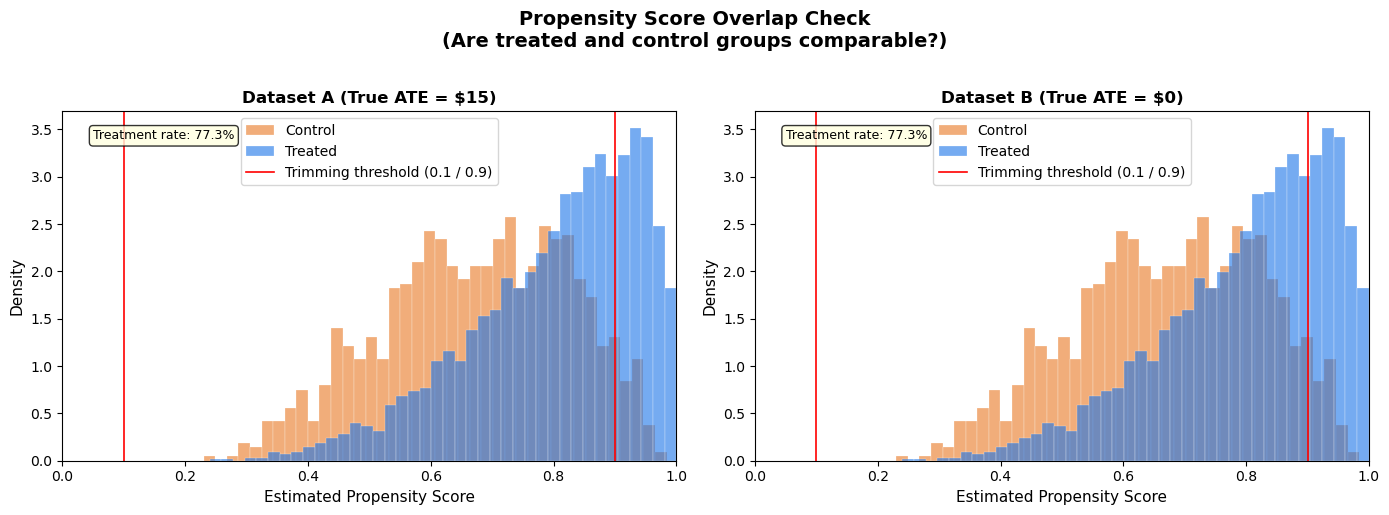

HOW TO READ: You want the blue and orange histograms to overlap.
Red dashed lines show the trimming thresholds (0.1 and 0.9).
Users outside these thresholds get extreme weights and cause instability.


In [21]:
plot_propensity_overlap(df_effect, df_no_effect)

In [22]:
# =============================================================================
# SECTION 5: COMPUTING IPW WEIGHTS
# =============================================================================

In [23]:
def compute_ipw_weights(df, ps_col="ps", trim_threshold=0.05,
                        stabilized=True):
    """
    Computes Inverse Probability Weights (IPW) for each user.

    What this function does:
    The key insight of IPW:
    - Treated users with a LOW propensity score were "surprisingly" treated.
      They represent many similar users who DIDN'T get treatment.
      We upweight them: weight = 1 / ps
    - Control users with a HIGH propensity score were "surprisingly" untreated.
      They represent many similar users who DID get treatment.
      We upweight them: weight = 1 / (1 - ps)

    By reweighting, we create a "pseudo-population" where treatment is no
    longer correlated with the confounders - like a randomized experiment.

    STABILIZED WEIGHTS:
    Instead of weight = 1/ps, use weight = P(T=1) / ps for treated users.
    Stabilized weights have better statistical properties (lower variance)
    and are always recommended in practice.

    TRIMMING:
    If ps is very close to 0 or 1, weights become enormous (e.g., 1/0.02 = 50).
    These extreme weights can dominate the analysis and inflate variance.
    Trimming clips the propensity score to [trim_threshold, 1-trim_threshold]
    before computing weights. Common choices: 0.01, 0.05, 0.10.

    WATCH OUT FOR:
    - Very high max weights (> 20-30) suggest poor overlap or model issues
    - High weight variance = high variance in your ATE estimate
    - Trimming reduces bias from extreme weights but introduces a tiny bit
      of its own bias - it's a bias-variance tradeoff

    Parameters:
        df              : dataset
        ps_col          : column name with propensity scores
        trim_threshold  : clips ps to [trim, 1-trim] to avoid extreme weights
        stabilized      : if True, use stabilized weights (recommended)

    Returns:
        Series of IPW weights, one per user
    """
    ps = df[ps_col].copy()
    treatment = df["treatment"]

    # Trim extreme propensity scores
    ps_trimmed = ps.clip(trim_threshold, 1 - trim_threshold)

    # Marginal treatment probability (used for stabilization)
    p_treat = treatment.mean()

    if stabilized:
        # Stabilized IPW weights
        weights = np.where(
            treatment == 1,
            p_treat / ps_trimmed,           # treated users
            (1 - p_treat) / (1 - ps_trimmed)  # control users
        )
    else:
        # Unstabilized IPW weights
        weights = np.where(
            treatment == 1,
            1.0 / ps_trimmed,
            1.0 / (1 - ps_trimmed)
        )

    return pd.Series(weights, index=df.index)

In [24]:
df_effect["ipw"] = compute_ipw_weights(df_effect, trim_threshold=0.05)
df_no_effect["ipw"] = compute_ipw_weights(df_no_effect, trim_threshold=0.05)

In [25]:
# Print weight diagnostics
for label, df in [("Dataset A", df_effect), ("Dataset B", df_no_effect)]:
    print(f"\n{label} - IPW Weight Summary:")
    print(df["ipw"].describe().round(3))
    print(f"  Effective Sample Size (ESS): {(df['ipw'].sum()**2 / (df['ipw']**2).sum()):.0f} "
          f"out of {len(df)} total")


Dataset A - IPW Weight Summary:
count    5000.000
mean        0.991
std         0.393
min         0.295
25%         0.821
50%         0.913
75%         1.080
max         4.540
Name: ipw, dtype: float64
  Effective Sample Size (ESS): 4321 out of 5000 total

Dataset B - IPW Weight Summary:
count    5000.000
mean        0.991
std         0.393
min         0.295
25%         0.821
50%         0.913
75%         1.080
max         4.540
Name: ipw, dtype: float64
  Effective Sample Size (ESS): 4321 out of 5000 total


In [26]:
# The Effective Sample Size (ESS) tells you how much statistical
# "power" you have after reweighting. If ESS << N, your weights are very
# unequal, meaning a few users are driving the analysis. ESS < 20% of N
# is a red flag - consider loosening the treatment targeting or trimming more.

In [27]:
# =============================================================================
# SECTION 6: WEIGHT DIAGNOSTICS
# =============================================================================

In [28]:
def plot_weight_diagnostics(df_a, df_b):
    """
    Plots the distribution of IPW weights for both datasets.

    What this chart shows:
    - Ideal weights are centered around 1 with moderate spread.
    - Heavy right tails (very large weights) indicate poor overlap.
      A few users with huge weights will dominate the estimate.
    - If you see weights > 20, that's worth investigating.

    HOW TO READ THIS CHART:
    - X-axis: weight value. Y-axis: number of users at that weight.
    - Most users should cluster near 1.0.
    - A long right tail = some users are being weighted up a LOT.
    - The vertical red dashed line at weight=10 is a rough "concern threshold".
      Users to the right of this line are potentially problematic.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("IPW Weight Distribution\n(Checking for extreme weights)",
                 fontsize=14, fontweight="bold")

    for ax, df, title in zip(axes, [df_a, df_b],
                              ["Dataset A (True ATE = $15)", "Dataset B (True ATE = $0)"]):
        w = df["ipw"]
        ax.hist(w, bins=60, color="#4CAF50", alpha=0.75, edgecolor="white", linewidth=0.3)
        ax.axvline(w.mean(), color="blue", linestyle="-", linewidth=1.5,
                   label=f"Mean weight: {w.mean():.2f}")
        ax.axvline(10, color="red", linestyle="-", linewidth=1.5,
                   label="Concern threshold (10)")

        pct_extreme = (w > 10).mean()
        ax.set_xlabel("IPW Weight", fontsize=11)
        ax.set_ylabel("Number of Users", fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.text(0.6, 0.85, f"Weights > 10: {pct_extreme:.1%}",
                transform=ax.transAxes, fontsize=9,
                color="red" if pct_extreme > 0.02 else "green",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

    plt.tight_layout()
    plt.show()
    print("HOW TO READ: Most weights should be close to 1.0.")
    print("A long right tail or weights > 10 mean some users are having")
    print("outsized influence. Consider trimming more aggressively.")

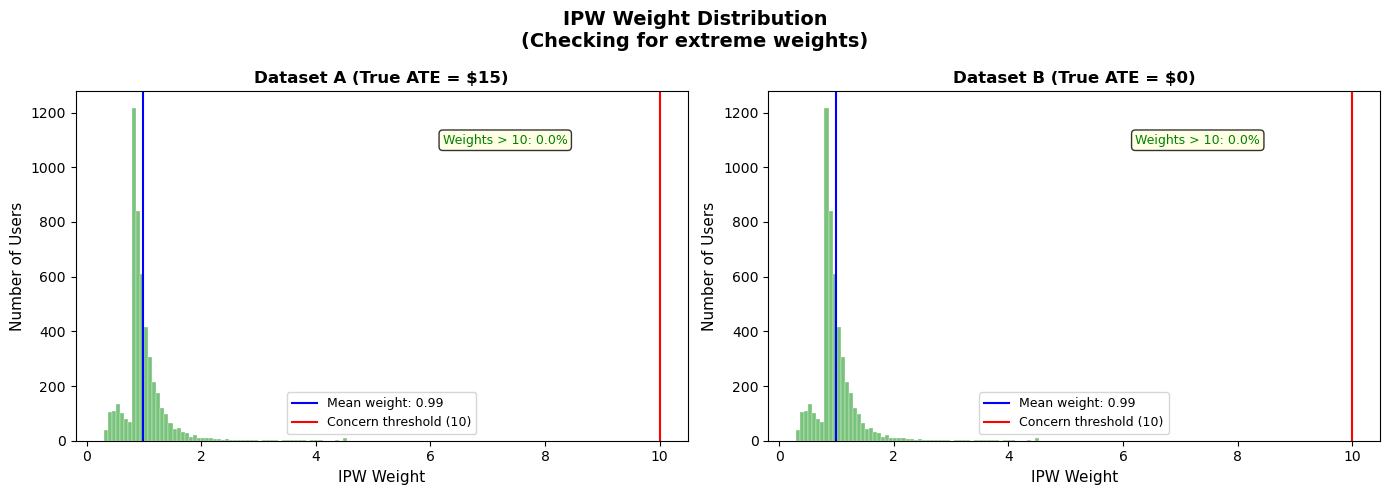

HOW TO READ: Most weights should be close to 1.0.
A long right tail or weights > 10 mean some users are having
outsized influence. Consider trimming more aggressively.


In [29]:
plot_weight_diagnostics(df_effect, df_no_effect)

In [30]:
# =============================================================================
# SECTION 7: COVARIATE BALANCE (THE GOLD STANDARD CHECK)
# =============================================================================

In [31]:
def compute_smd(df, covariates, weight_col=None):
    """
    Computes the Standardized Mean Difference (SMD) for each covariate,
    before and after IPW reweighting.

    What this function does:
    - SMD measures how different treated and control users are on each feature.
    - SMD = (mean_treated - mean_control) / pooled_std
    - Before IPW: SMD reflects the selection bias in the data.
    - After IPW:  SMD should be close to 0 - meaning the weighted treated
                  and weighted control groups look similar on all covariates.
    - If after-IPW SMD is still large (rule of thumb: |SMD| > 0.1), your
      propensity model may be misspecified. Try adding interaction terms or
      using a more flexible model.

    Returns:
        DataFrame with SMD before and after weighting for each covariate
    """
    results = []
    for col in covariates:
        t = df[df.treatment == 1][col]
        c = df[df.treatment == 0][col]
        pooled_std = np.sqrt((t.var() + c.var()) / 2)

        smd_raw = (t.mean() - c.mean()) / pooled_std

        if weight_col is not None:
            wt = df[df.treatment == 1][weight_col]
            wc = df[df.treatment == 0][weight_col]
            t_mean_w = np.average(t, weights=wt)
            c_mean_w = np.average(c, weights=wc)
            smd_wtd = (t_mean_w - c_mean_w) / pooled_std
        else:
            smd_wtd = np.nan

        results.append({"covariate": col, "SMD_raw": smd_raw, "SMD_weighted": smd_wtd})

    return pd.DataFrame(results)

In [32]:
def plot_love_plot(df_a, df_b):
    """
    Creates a Love Plot: a visual check of covariate balance before and
    after IPW weighting.

    What this chart shows:
    - Each dot represents a covariate.
    - X-axis: Standardized Mean Difference (SMD). Closer to 0 = more balanced.
    - Blue dots = before weighting. Green dots = after weighting.
    - The grey shaded band shows the acceptable range: |SMD| < 0.1
    - GOOD result: green dots move INTO the grey band (near zero).
    - BAD result: green dots remain far from zero = your PS model is failing
      to balance the groups. Fix: add more covariates, interactions, or use
      a more flexible model (e.g., gradient boosting for propensity estimation).

    HOW TO READ THIS CHART:
    - Look at the green (after-weighting) dots.
    - If ALL green dots fall within the grey band: balance is achieved.
    - If any green dot is outside the band: that covariate is still confounding.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Love Plot: Covariate Balance Before vs After IPW\n"
                 "(Green dots should land inside the grey band)",
                 fontsize=14, fontweight="bold")

    for ax, df, title in zip(axes, [df_a, df_b],
                              ["Dataset A (True ATE = $15)", "Dataset B (True ATE = $0)"]):
        balance = compute_smd(df, COVARIATES, weight_col="ipw")

        y_pos = range(len(COVARIATES))
        ax.axvspan(-0.1, 0.1, alpha=0.15, color="grey", label="Acceptable range (|SMD| < 0.1)")
        ax.axvline(0, color="black", linewidth=0.8, linestyle="-")

        ax.scatter(balance["SMD_raw"], y_pos, color="#1A73E8", s=90,
                   label="Before IPW", zorder=5)
        ax.scatter(balance["SMD_weighted"], y_pos, color="#34A853", s=90,
                   marker="D", label="After IPW", zorder=5)

        # Draw lines connecting before/after for each covariate
        for i, row in balance.iterrows():
            ax.plot([row["SMD_raw"], row["SMD_weighted"]], [i, i],
                    color="grey", linewidth=0.8, alpha=0.5, linestyle="-")

        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(balance["covariate"], fontsize=10)
        ax.set_xlabel("Standardized Mean Difference (SMD)", fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9, loc="lower right")
        ax.set_xlim(-1.2, 1.2)

    plt.tight_layout()
    plt.show()
    print("HOW TO READ: Green diamonds = after IPW. They should fall in the grey band.")
    print("If a green diamond is still far from 0, the IPW did NOT balance that feature.")
    print("Fix: Add interaction terms, polynomial features, or use GBM for PS estimation.")

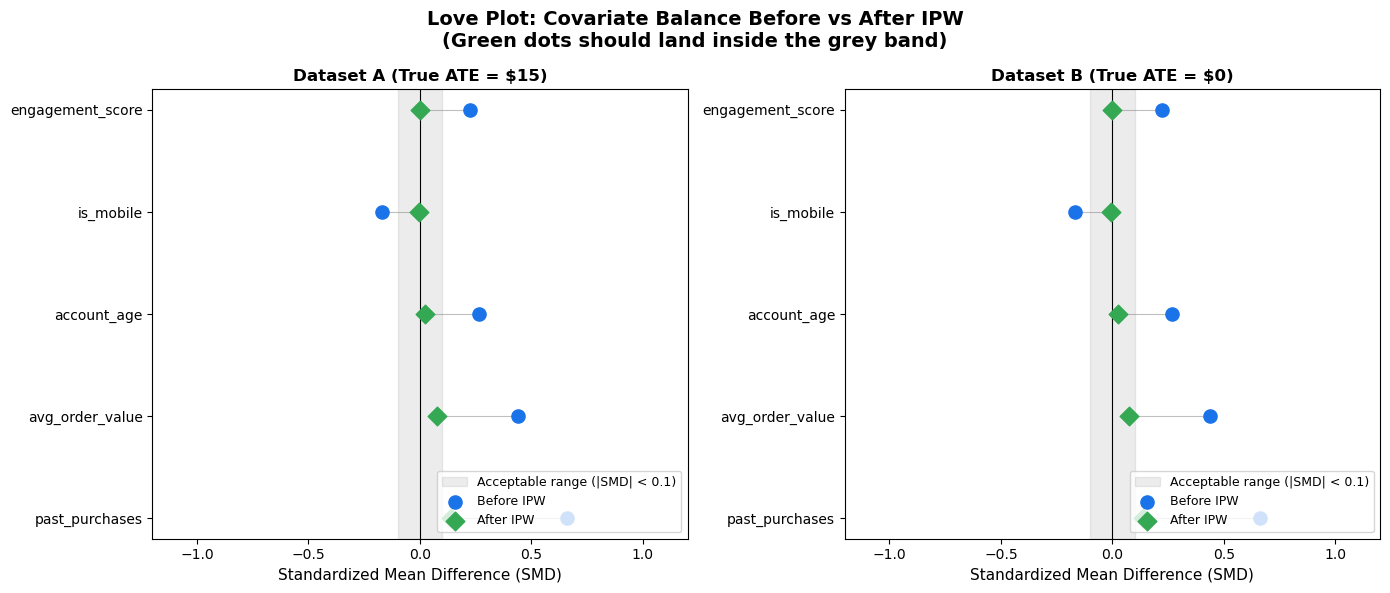

HOW TO READ: Green diamonds = after IPW. They should fall in the grey band.
If a green diamond is still far from 0, the IPW did NOT balance that feature.
Fix: Add interaction terms, polynomial features, or use GBM for PS estimation.


In [33]:
plot_love_plot(df_effect, df_no_effect)

In [34]:
# =============================================================================
# SECTION 8: IPW ESTIMATE OF ATE
# =============================================================================

In [53]:
def ipw_ate(df, outcome_col="spending", treatment_col="treatment",
            weight_col="ipw"):
    """
    Estimates the Average Treatment Effect (ATE) using the
    Horvitz-Thompson IPW estimator.

    What this function does:
    - In the reweighted pseudo-population, treated and control groups look
      similar. So we just take weighted means and subtract.
    - ATE = weighted_mean(outcome | treated) - weighted_mean(outcome | control)

    This is the Horvitz-Thompson estimator. It is consistent (converges to
    the true ATE) when the propensity model is correctly specified AND
    the positivity assumption holds.

    Returns:
        (ate_estimate, treated_weighted_mean, control_weighted_mean)
    """
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]

    mu1 = np.average(treated[outcome_col], weights=treated[weight_col])
    mu0 = np.average(control[outcome_col], weights=control[weight_col])

    return mu1 - mu0, mu1, mu0

In [ ]:
#How do we apply weights
# Not to features. The weights are applied to the outcome when computing means.
#np.average(x, weights=w) computes sum(w * x) / sum(w). 
#So you are taking a weighted average of spending, where each user's spending is weighted by their IPW weight.

In [36]:
ate_a, mu1_a, mu0_a = ipw_ate(df_effect)
ate_b, mu1_b, mu0_b = ipw_ate(df_no_effect)

In [37]:
print("\n" + "=" * 60)
print("IPW ESTIMATES (CAUSAL)")
print("=" * 60)
print(f"Dataset A (True ATE=$15): IPW estimate = ${ate_a:.2f}  |  Naive = ${naive_a:.2f}")
print(f"Dataset B (True ATE=$0):  IPW estimate = ${ate_b:.2f}  |  Naive = ${naive_b:.2f}")


IPW ESTIMATES (CAUSAL)
Dataset A (True ATE=$15): IPW estimate = $16.73  |  Naive = $25.50
Dataset B (True ATE=$0):  IPW estimate = $1.74  |  Naive = $10.50


In [38]:
# IPW should now be much closer to $15 for Dataset A and close to $0
# for Dataset B. Compare this to the naive estimates, which were wildly off.
# The difference between naive and IPW is the confounding bias that was removed.

In [39]:
# =============================================================================
# SECTION 9: CONFIDENCE INTERVALS VIA BOOTSTRAP
# =============================================================================

In [40]:
def bootstrap_ipw_ate(df, n_bootstrap=500, trim_threshold=0.05, seed=99):
    """
    Estimates confidence intervals for the IPW ATE using the bootstrap.

    What this function does:
    - Repeats the full IPW pipeline (propensity estimation + weighting +
      ATE estimation) on many random resamples of the data.
    - The spread of ATE estimates across bootstrap samples gives us the
      uncertainty around our estimate.

    IMPORTANT: Bootstrap for IPW must re-estimate the propensity score on
    each resample. Do NOT just resample the weights - that underestimates
    uncertainty.

    WATCH OUT FOR:
    - If bootstrap CIs are very wide, your estimate is unreliable.
    - This is often caused by extreme weights (poor overlap) or small N.

    Parameters:
        df            : dataset
        n_bootstrap   : number of bootstrap resamples (500 is enough for 95% CI)
        trim_threshold: same trimming as main analysis

    Returns:
        (lower_95, upper_95, all_estimates)
    """
    rng = np.random.default_rng(seed)
    ates = []

    for _ in range(n_bootstrap):
        # Resample with replacement
        sample = df.sample(n=len(df), replace=True, random_state=rng.integers(1e6))
        sample = sample.reset_index(drop=True)

        # Re-estimate propensity on the resample (CRITICAL)
        sample["ps_boot"] = estimate_propensity(sample, COVARIATES)
        sample["ipw_boot"] = compute_ipw_weights(sample, ps_col="ps_boot",
                                                  trim_threshold=trim_threshold)

        ate_boot, _, _ = ipw_ate(sample, weight_col="ipw_boot")
        ates.append(ate_boot)

    ates = np.array(ates)
    lower = np.percentile(ates, 2.5)
    upper = np.percentile(ates, 97.5)
    return lower, upper, ates

In [41]:
print("\nRunning bootstrap CI estimation (this takes ~30 seconds)...")
ci_lower_a, ci_upper_a, boot_ates_a = bootstrap_ipw_ate(df_effect, n_bootstrap=300)
ci_lower_b, ci_upper_b, boot_ates_b = bootstrap_ipw_ate(df_no_effect, n_bootstrap=300)

print(f"\nDataset A: IPW ATE = ${ate_a:.2f}  [95% CI: ${ci_lower_a:.2f}, ${ci_upper_a:.2f}]")
print(f"Dataset B: IPW ATE = ${ate_b:.2f}  [95% CI: ${ci_lower_b:.2f}, ${ci_upper_b:.2f}]")
print("\nTrue ATE (Dataset A): $15.00")
print("True ATE (Dataset B): $0.00")


Running bootstrap CI estimation (this takes ~30 seconds)...

Dataset A: IPW ATE = $16.73  [95% CI: $15.71, $17.65]
Dataset B: IPW ATE = $1.74  [95% CI: $0.72, $2.65]

True ATE (Dataset A): $15.00
True ATE (Dataset B): $0.00


In [42]:
# =============================================================================
# SECTION 10: BOOTSTRAP DISTRIBUTION CHART
# =============================================================================

In [43]:
def plot_bootstrap_distributions(boot_a, boot_b, ate_a, ate_b,
                                  ci_a, ci_b):
    """
    Plots the bootstrap distribution of IPW ATE estimates for both datasets.

    What this chart shows:
    - Each bar represents a bootstrap sample's ATE estimate.
    - The distribution tells us how certain we are about the true ATE.
    - A narrow distribution = precise estimate. Wide = uncertain.
    - The vertical dashed lines show the true ATE and our CI bounds.

    HOW TO READ THIS CHART:
    - Dataset A: The distribution should be centered near $15 with a
      95% CI that DOES NOT cross zero. This means we have strong evidence
      the coupon caused a real spending increase.
    - Dataset B: The distribution should be centered near $0 and the
      95% CI WILL cross zero. This means we CANNOT conclude the coupon
      had any effect (we would fail to reject the null).
    - When the CI does not include 0, the effect is statistically significant.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Bootstrap Distribution of IPW ATE Estimates\n"
                 "(How certain are we about the causal effect?)",
                 fontsize=14, fontweight="bold")

    configs = [
        (axes[0], boot_a, ate_a, ci_a, "$15.00", "Dataset A (True ATE = $15)"),
        (axes[1], boot_b, ate_b, ci_b, "$0.00", "Dataset B (True ATE = $0)"),
    ]

    for ax, boot, ate, ci, true_val_str, title in configs:
        ax.hist(boot, bins=40, color="#1A73E8", alpha=0.75, edgecolor="white",
                linewidth=0.3)
        ax.axvline(ate, color="blue", linewidth=2, label=f"IPW ATE: ${ate:.2f}")
        ax.axvline(ci[0], color="red", linewidth=1.5, linestyle="-",
                   label=f"95% CI: [${ci[0]:.2f}, ${ci[1]:.2f}]")
        ax.axvline(ci[1], color="red", linewidth=1.5, linestyle="-")
        ax.axvline(0, color="black", linewidth=1.5, linestyle="-", label="Zero line")

        ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 50],
                          ci[0], ci[1], alpha=0.1, color="red")

        ci_crosses_zero = ci[0] < 0 < ci[1]
        conclusion = "CI crosses 0 => No significant effect" if ci_crosses_zero \
                     else "CI excludes 0 => Significant effect"
        color = "red" if ci_crosses_zero else "green"

        ax.text(0.05, 0.92, conclusion, transform=ax.transAxes, fontsize=9,
                color=color,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
        ax.set_xlabel("ATE Estimate ($)", fontsize=11)
        ax.set_ylabel("Bootstrap Frequency", fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    print("HOW TO READ: Dataset A CI should NOT cross 0 (real effect).")
    print("Dataset B CI SHOULD cross 0 (no effect, can't distinguish from noise).")

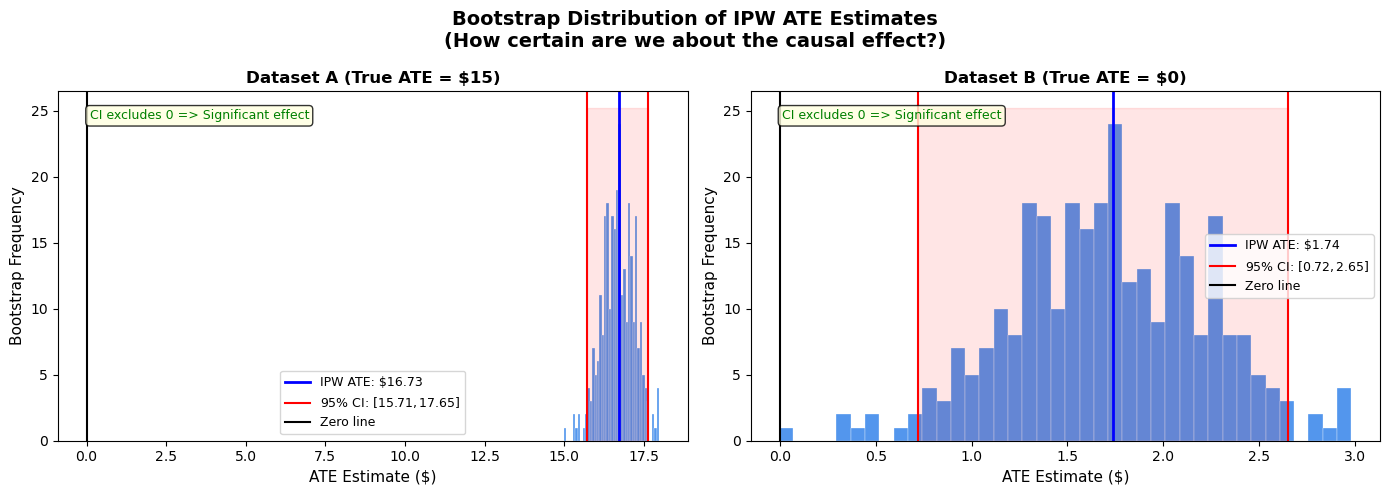

HOW TO READ: Dataset A CI should NOT cross 0 (real effect).
Dataset B CI SHOULD cross 0 (no effect, can't distinguish from noise).


In [44]:
plot_bootstrap_distributions(
    boot_ates_a, boot_ates_b, ate_a, ate_b,
    (ci_lower_a, ci_upper_a), (ci_lower_b, ci_upper_b)
)

In [45]:
# =============================================================================
# SECTION 11: FINAL SUMMARY COMPARISON CHART
# =============================================================================

In [46]:
def plot_final_summary(naive_a, naive_b, ate_a, ate_b,
                        ci_a, ci_b):
    """
    Final summary chart comparing naive vs IPW estimates for both datasets,
    alongside the true ATE values.

    What this chart shows:
    - For Dataset A: Naive estimate is too high (confounding inflates it).
      IPW estimate recovers the true $15 effect.
    - For Dataset B: Naive estimate is high even though there is NO real effect.
      IPW estimate recovers ~$0, correctly showing no causal effect.

    This is the key story of causal inference with IPW - it removes
    the systematic bias introduced by non-random treatment assignment.

    HOW TO READ:
    - Red bar = naive (biased) estimate
    - Green bar = IPW (causal) estimate
    - Dashed black line = true ATE
    - Error bars on the IPW estimate = 95% bootstrap CI
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle("Naive vs IPW Estimates: Recovering True Causal Effects",
                 fontsize=14, fontweight="bold")

    configs = [
        (axes[0], naive_a, ate_a, ci_a, 15.0, "Dataset A\n(True ATE = $15)"),
        (axes[1], naive_b, ate_b, ci_b, 0.0,  "Dataset B\n(True ATE = $0)"),
    ]

    for ax, naive, ipw_est, ci, true_ate, title in configs:
        bars = ax.bar(["Naive\n(Biased)", "IPW\n(Causal)"],
                      [naive, ipw_est],
                      color=["#E53935", "#43A047"],
                      width=0.45, alpha=0.85, edgecolor="black", linewidth=0.7)

        # Error bars on IPW only
        ci_lo, ci_hi = ci
        ax.errorbar(1, ipw_est, yerr=[[ipw_est - ci_lo], [ci_hi - ipw_est]],
                    fmt="none", color="black", capsize=6, linewidth=2)

        ax.axhline(true_ate, color="black", linewidth=2, linestyle="-",
                   label=f"True ATE: ${true_ate:.0f}")

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_ylabel("ATE Estimate ($)", fontsize=11)
        ax.legend(fontsize=10)
        ax.set_ylim(min(-5, true_ate - 5), max(naive + 10, true_ate + 10))

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
                    f"${height:.1f}", ha="center", va="bottom", fontsize=10,
                    fontweight="bold")

    plt.tight_layout()
    plt.show()
    print("HOW TO READ: The green (IPW) bar should be close to the black dashed line.")
    print("Dataset A: IPW correctly finds ~$15. Dataset B: IPW correctly finds ~$0.")
    print("Red bars are inflated by confounding in both cases.")

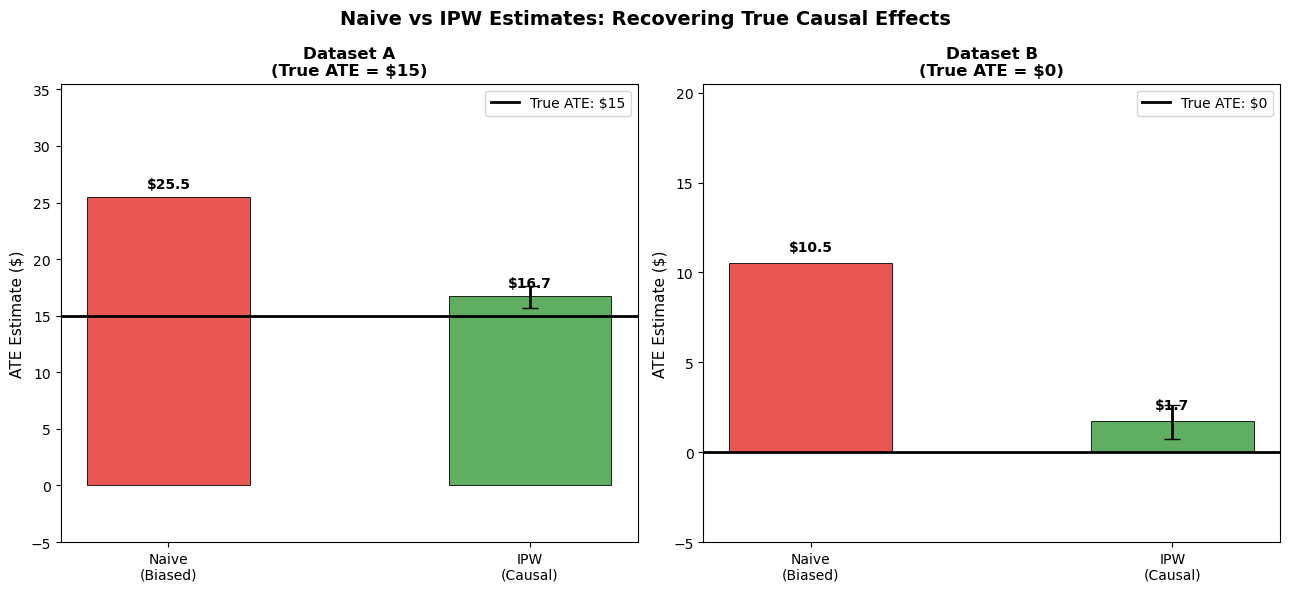

HOW TO READ: The green (IPW) bar should be close to the black dashed line.
Dataset A: IPW correctly finds ~$15. Dataset B: IPW correctly finds ~$0.
Red bars are inflated by confounding in both cases.


In [47]:
plot_final_summary(naive_a, naive_b, ate_a, ate_b,
                   (ci_lower_a, ci_upper_a), (ci_lower_b, ci_upper_b))

In [48]:
# =============================================================================
# SECTION 12: CALIBRATION CHECK (BONUS - PROPENSITY MODEL QUALITY)
# =============================================================================

In [49]:
def plot_calibration(df_a, df_b):
    """
    Plots calibration curves for the estimated propensity scores.

    What this chart shows:
    - Calibration asks: when the model says P(treatment)=0.7, do 70% of those
      users actually get treated?
    - Perfect calibration = the calibration curve follows the 45-degree line.
    - Poor calibration means your propensity scores are systematically wrong
      (e.g., always predicting 0.6 when the true rate is 0.3).
    - Poorly calibrated PS models produce biased IPW estimates.

    HOW TO READ:
    - X-axis: what the model predicts (mean predicted probability in each bin)
    - Y-axis: what actually happens (fraction of treated users in that bin)
    - Dots close to the diagonal line = well calibrated
    - Dots below the line = model overpredicts treatment probability
    - Dots above the line = model underpredicts treatment probability
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Propensity Score Calibration\n"
                 "(Does the model's predicted probability match reality?)",
                 fontsize=14, fontweight="bold")

    for ax, df, title in zip(axes, [df_a, df_b],
                              ["Dataset A", "Dataset B"]):
        prob_true, prob_pred = calibration_curve(
            df["treatment"], df["ps"], n_bins=10
        )
        ax.plot([0, 1], [0, 1], "k-", linewidth=1.5, label="Perfect calibration")
        ax.plot(prob_pred, prob_true, "o-", color="#1A73E8", linewidth=2,
                markersize=8, label="Model calibration")
        ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color="#1A73E8")

        ax.set_xlabel("Mean Predicted Probability", fontsize=11)
        ax.set_ylabel("Fraction of Treated Users", fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()
    print("HOW TO READ: Dots should be close to the black dashed 45-degree line.")
    print("Systematic deviations = propensity model is miscalibrated.")
    print("Fix: Use Platt scaling or isotonic regression to recalibrate.")


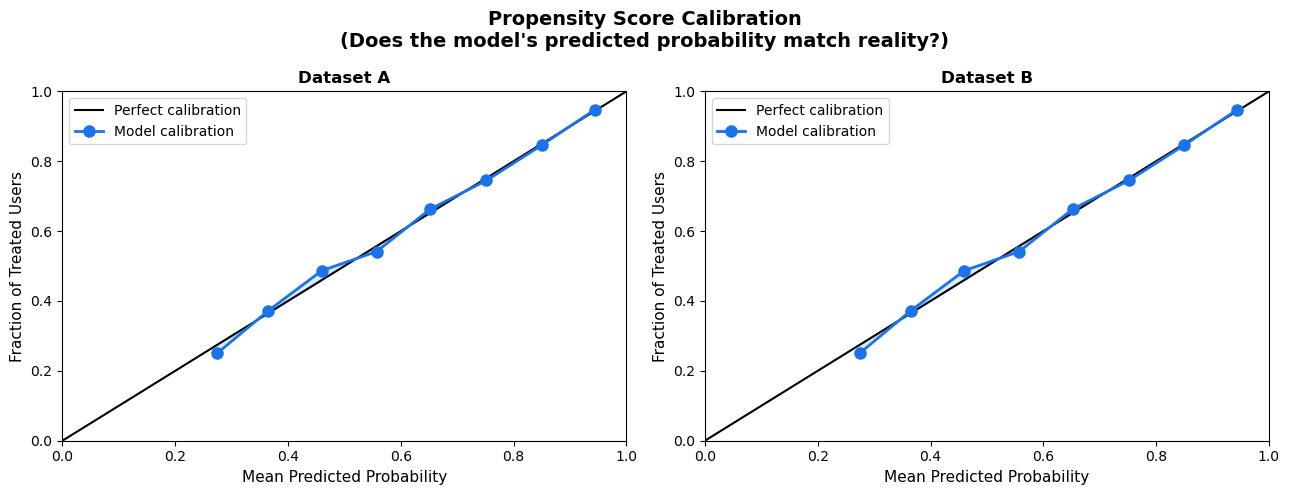

HOW TO READ: Dots should be close to the black dashed 45-degree line.
Systematic deviations = propensity model is miscalibrated.
Fix: Use Platt scaling or isotonic regression to recalibrate.


In [50]:
plot_calibration(df_effect, df_no_effect)

In [51]:
# =============================================================================
# FINAL PRINTOUT
# =============================================================================

In [52]:
print("\n" + "=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"{'Method':<30} {'Dataset A':<20} {'Dataset B':<20}")
print("-" * 65)
print(f"{'True ATE':<30} {'$15.00':<20} {'$0.00':<20}")
print(f"{'Naive (biased)':<30} ${naive_a:<19.2f} ${naive_b:<19.2f}")
print(f"{'IPW ATE':<30} ${ate_a:<19.2f} ${ate_b:<19.2f}")
print(f"{'95% Bootstrap CI':<30} "
      f"[${ci_lower_a:.2f}, ${ci_upper_a:.2f}]    "
      f"[${ci_lower_b:.2f}, ${ci_upper_b:.2f}]")
print("-" * 65)
print(f"\nConclusion A: CI = [{ci_lower_a:.2f}, {ci_upper_a:.2f}] - "
      f"{'EXCLUDES zero => significant effect' if ci_lower_a > 0 else 'crosses zero => no significant effect'}")
print(f"Conclusion B: CI = [{ci_lower_b:.2f}, {ci_upper_b:.2f}] - "
      f"{'EXCLUDES zero => significant effect' if ci_lower_b > 0 else 'crosses zero => no significant effect'}")

print("""
KEY TAKEAWAYS FOR DS:
-------
1. CONFOUNDING BIAS IS REAL: The naive estimate was wrong in BOTH datasets,
   even when the true effect was zero. Never compare raw treated vs control.

2. IPW CREATES A PSEUDO-RCT: By reweighting, we simulate what would happen
   in a randomized experiment. The weighted groups are comparable.

3. ALWAYS CHECK BALANCE: The Love Plot (SMD chart) is your diagnostic.
   If after-IPW SMDs are not near zero, your model is misspecified.

4. POSITIVITY MATTERS: If certain user types are NEVER treated (or always
   treated), IPW cannot recover the ATE for those users. Check overlap plots.

5. STABILIZED + TRIMMED WEIGHTS: Always use stabilized weights. Trim extreme
   PS values (common threshold: 0.01-0.10) to reduce variance.

6. BOOTSTRAP YOUR CIs: Standard errors for IPW are complex. Bootstrap is
   the safest and most flexible approach for inference.

7. UNMEASURED CONFOUNDING: IPW only adjusts for OBSERVED confounders.
   If there are unmeasured variables that affect both treatment and outcome
   (e.g., user intent to buy), IPW will still be biased. This is the
   core limitation and cannot be solved without better data design.
""")


FINAL RESULTS SUMMARY
Method                         Dataset A            Dataset B           
-----------------------------------------------------------------
True ATE                       $15.00               $0.00               
Naive (biased)                 $25.50               $10.50              
IPW ATE                        $16.73               $1.74               
95% Bootstrap CI               [$15.71, $17.65]    [$0.72, $2.65]
-----------------------------------------------------------------

Conclusion A: CI = [15.71, 17.65] - EXCLUDES zero => significant effect
Conclusion B: CI = [0.72, 2.65] - EXCLUDES zero => significant effect

KEY TAKEAWAYS FOR DS:
-------
1. CONFOUNDING BIAS IS REAL: The naive estimate was wrong in BOTH datasets,
   even when the true effect was zero. Never compare raw treated vs control.

2. IPW CREATES A PSEUDO-RCT: By reweighting, we simulate what would happen
   in a randomized experiment. The weighted groups are comparable.

3. ALWAYS CHECK 

In [ ]:
#Enhancement

# =============================================================================
# HOW AIPW (DOUBLY ROBUST) WORKS -- SUMMARY
# =============================================================================

# STEP 1: Fit two models independently (they do NOT feed into each other)
#
#   Model 1 -- Propensity model:
#     Input  : user covariates X (purchases, order value, engagement, etc.)
#     Output : P(T=1 | X) -- probability each user gets treated
#
#   Model 2 -- Outcome model:
#     Input  : user covariates X + treatment column T (0 or 1)
#     Output : E(Y | T, X) -- predicted spending for each user

# STEP 2: Ask the outcome model two counterfactual questions per user
#
#   mu1_hat = predicted spending if we FORCE T=1 for every user
#   mu0_hat = predicted spending if we FORCE T=0 for every user
#   (you run the same user through the outcome model twice)

# STEP 3: Compute the AIPW estimate
#
#   ATE = mean[
#       (mu1_hat - mu0_hat)                       # baseline from outcome model
#     + (T / ps) * (Y - mu1_hat)                  # bias correction for treated
#     - ((1-T) / (1-ps)) * (Y - mu0_hat)          # bias correction for control
#   ]
#
#   The correction terms are: residual (actual - predicted) * IPW weight
#   If outcome model is perfect  --> residuals = 0, correction vanishes
#   If propensity model is perfect --> correction fully fixes outcome model error
#   If both are roughly right --> errors partially cancel, better than either alone

# WHY IT IS CALLED DOUBLY ROBUST:
#   Your ATE is consistent if EITHER model is correctly specified.
#   Two models = two chances to get it right.
#   One model wrong + one model right = still okay.
#   Both models wrong = not okay.

# HOW IT DIFFERS FROM PLAIN IPW:
#   IPW    : only Model 1. One chance. Outcome model does not exist.
#   AIPW   : Model 1 + Model 2 running in parallel. Combined in Step 3.